
# Multilayer Perceptron Depth Experiment
## Impact of Hidden Layer Depth on Neural Network Performance
#### **Dataset**: Fashion-MNIST


#### Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report

sns.set_palette("colorblind")
plt.rcParams["figure.figsize"] = (8,6)

print("Libraries successfully imported.")

Libraries successfully imported.


#### Load Fashion-MNIST Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: (60000, 28, 28)
Test samples: (10000, 28, 28)


#### Data Preprocessing

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Data normalized successfully.")

Data normalized successfully.


#### Class Labels

In [5]:
class_names = [
"T-shirt","Trouser","Pullover","Dress","Coat",
"Sandal","Shirt","Sneaker","Bag","Ankle boot"
]

#### Dataset Visualization

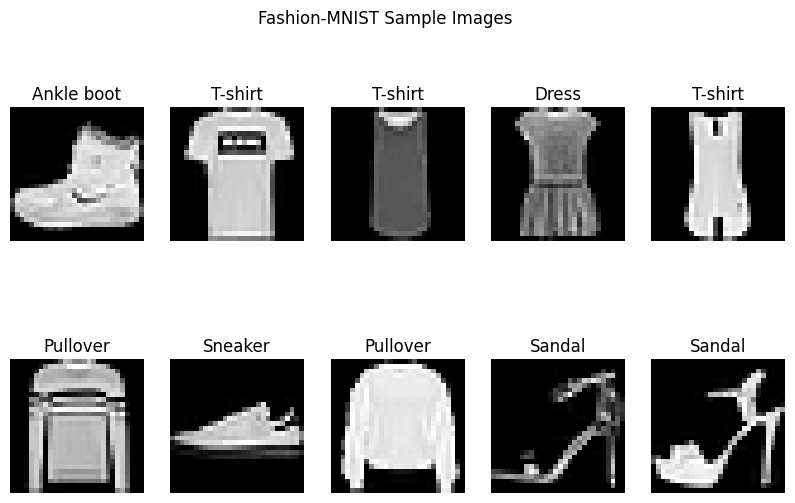

In [6]:
plt.figure(figsize=(10,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.suptitle("Fashion-MNIST Sample Images")

plt.savefig("figure1_dataset_samples.png", dpi=300, bbox_inches="tight")

plt.show()

#### MLP Model Function

In [7]:
def build_mlp_model(hidden_layers):

    model = Sequential()

    model.add(Flatten(input_shape=(28,28)))

    for _ in range(hidden_layers):
        model.add(Dense(128, activation="relu"))

    model.add(Dense(10, activation="softmax"))

    model.compile(
        optimizer=Adam(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

#### Train Models with Different Depths

In [21]:
depth_list = [1,2,3,4,5]

history_results = {}
accuracy_results = {}

for depth in depth_list:

    print(f"\nTraining model with {depth} hidden layer(s)")

    model = build_mlp_model(depth)

    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    history_results[depth] = history

    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    accuracy_results[depth] = test_accuracy

    print("Test accuracy:", test_accuracy)


Training model with 1 hidden layer(s)
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7990 - loss: 0.5835 - val_accuracy: 0.8501 - val_loss: 0.4426
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8536 - loss: 0.4201 - val_accuracy: 0.8587 - val_loss: 0.4064
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8670 - loss: 0.3768 - val_accuracy: 0.8611 - val_loss: 0.3979
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8740 - loss: 0.3530 - val_accuracy: 0.8659 - val_loss: 0.3691
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8822 - loss: 0.3267 - val_accuracy: 0.8784 - val_loss: 0.3455
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8883 - loss: 0.3091 - val_accuracy: 0.8733 - val_loss: 0.3496
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8906 - loss: 0.3001 - val_accuracy: 0.8791 - val_loss: 0.3371
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0

#### Training Accuracy Plot

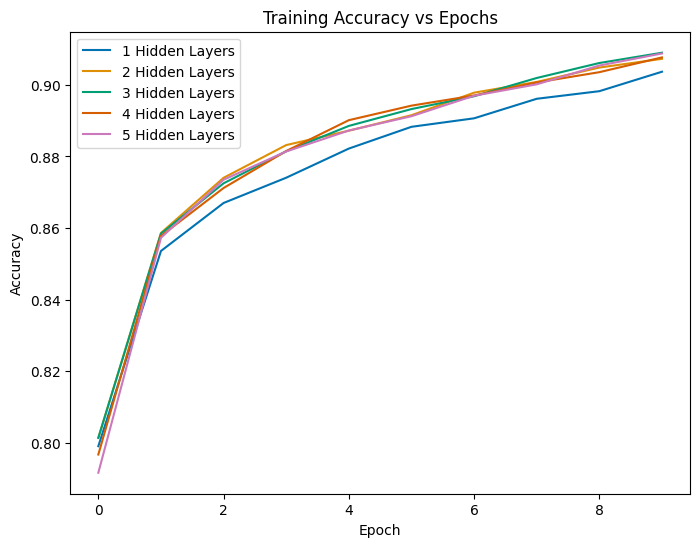

In [22]:
plt.figure()

for depth in depth_list:
    plt.plot(
        history_results[depth].history["accuracy"],
        label=f"{depth} Hidden Layers"
    )

plt.title("Training Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("figure2_training_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

#### Validation Accuracy Plot

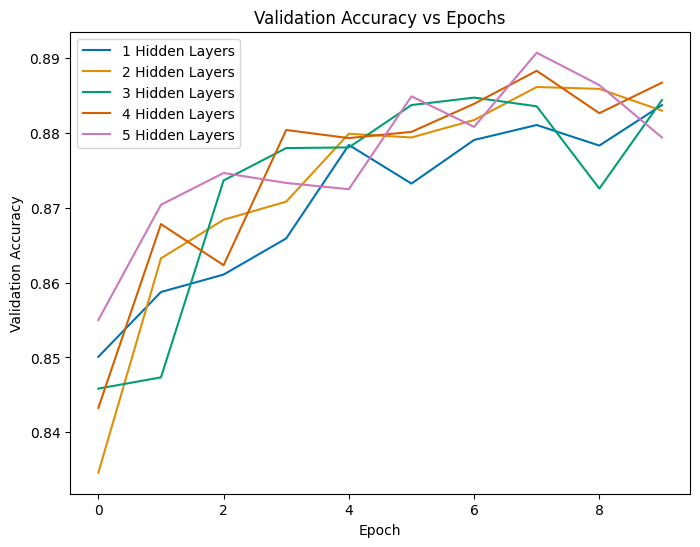

In [23]:
plt.figure()

for depth in depth_list:
    plt.plot(
        history_results[depth].history["val_accuracy"],
        label=f"{depth} Hidden Layers"
    )

plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.savefig("figure3_validation_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

#### Training Loss Plot

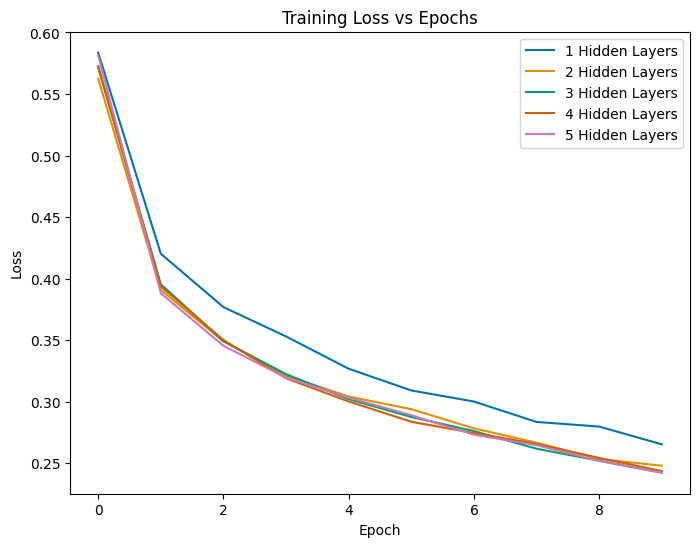

In [24]:
# Training Loss vs Epochs
plt.figure()

for depth in depth_list:
    plt.plot(
        history_results[depth].history["loss"],
        label=f"{depth} Hidden Layers"
    )

plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("figure4_training_loss.png", dpi=300, bbox_inches="tight")

plt.show()

#### Accuracy vs Network Depth

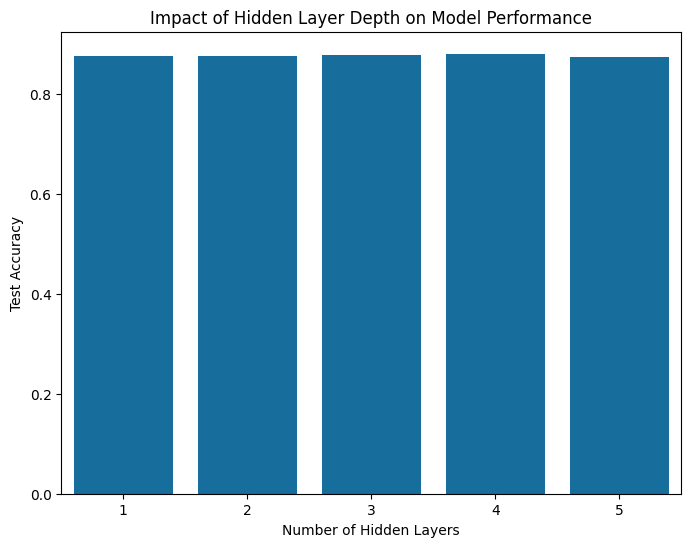

In [25]:

depths = list(accuracy_results.keys())
accuracies = list(accuracy_results.values())

plt.figure()

sns.barplot(x=depths, y=accuracies)

plt.xlabel("Number of Hidden Layers")
plt.ylabel("Test Accuracy")
plt.title("Impact of Hidden Layer Depth on Model Performance")

plt.savefig("figure5_depth_vs_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

Train Best Model

In [26]:
best_depth = max(accuracy_results, key=accuracy_results.get)

print("Best performing depth:", best_depth)

best_model = build_mlp_model(best_depth)

best_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Best performing depth: 4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7959 - loss: 0.5780 - val_accuracy: 0.8330 - val_loss: 0.4583
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8576 - loss: 0.3904 - val_accuracy: 0.8537 - val_loss: 0.4175
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8699 - loss: 0.3498 - val_accuracy: 0.8702 - val_loss: 0.3513
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8831 - loss: 0.3179 - val_accuracy: 0.8690 - val_loss: 0.3622
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8866 - loss: 0.3054 - val_accuracy: 0.8807 - val_loss: 0.3314
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8939 - loss: 0.2842 - val_accuracy: 0.8844 - val_loss: 0.3199
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8991 - loss: 0.2697 - val_accuracy: 0.8755 - val_loss: 0.3375
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9007 - loss: 0.2615 - val_accuracy: 

#### Predictions

In [27]:
y_pred_probs = best_model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


#### Classification Report

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.85      0.83      1000
           1       0.98      0.98      0.98      1000
           2       0.71      0.89      0.79      1000
           3       0.86      0.90      0.88      1000
           4       0.80      0.78      0.79      1000
           5       0.96      0.98      0.97      1000
           6       0.82      0.53      0.64      1000
           7       0.95      0.93      0.94      1000
           8       0.97      0.97      0.97      1000
           9       0.95      0.96      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000



#### Confusion Matrix

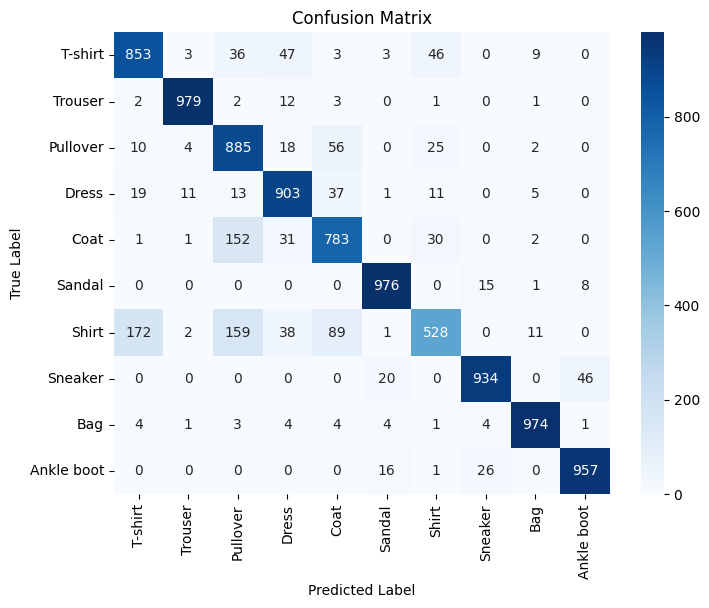

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig("figure6_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

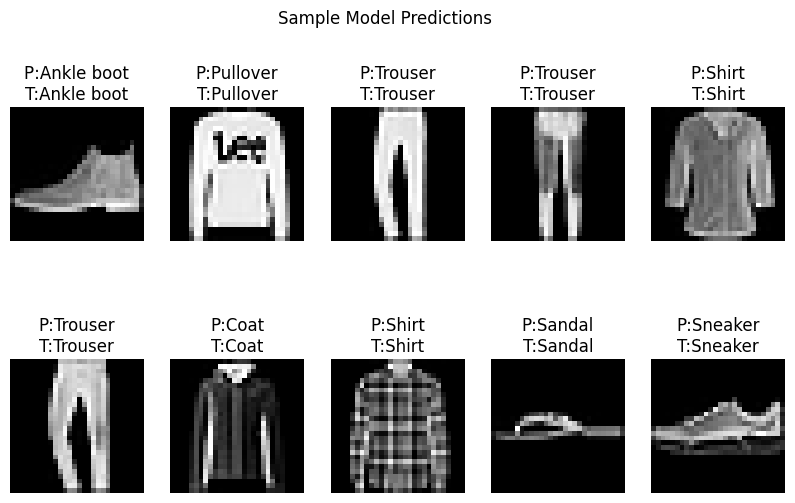

In [30]:
# Show Sample Predictions


plt.figure(figsize=(10,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i], cmap="gray")

    pred_label = class_names[y_pred[i]]

    true_label = class_names[y_test[i]]

    plt.title(f"P:{pred_label}\nT:{true_label}")

    plt.axis("off")

plt.suptitle("Sample Model Predictions")

plt.savefig("figure7_prediction_examples.png", dpi=300, bbox_inches="tight")

plt.show()

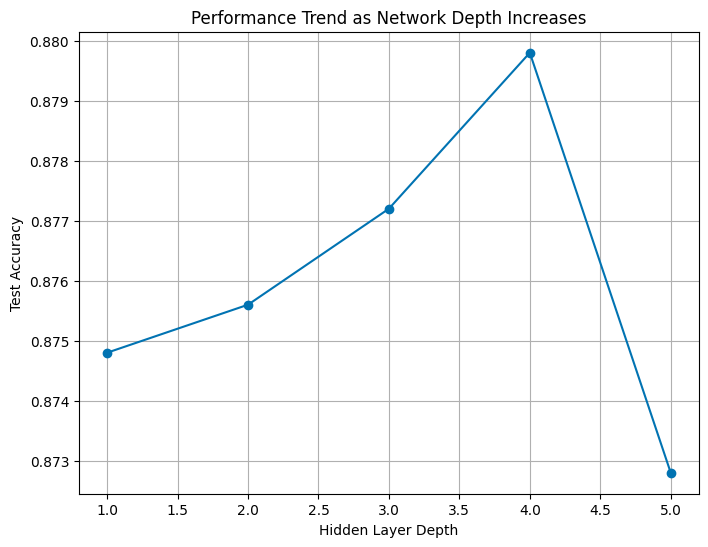

In [31]:
# Accuracy Trend Across Depth

plt.figure()

plt.plot(depths, accuracies, marker="o")

plt.xlabel("Hidden Layer Depth")
plt.ylabel("Test Accuracy")
plt.title("Performance Trend as Network Depth Increases")

plt.grid(True)

plt.savefig("figure8_depth_trend.png", dpi=300, bbox_inches="tight")

plt.show()